In [1]:
from pathlib import Path

IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def show_tree(folder, depth=0, max_depth=5):
    folder = Path(folder)

    if not folder.exists():
        print("Folder not found:", folder)
        return

    n = sum(
        1 for f in folder.rglob("*")
        if f.is_file() and f.suffix.lower() in IMG_EXT
    )

    print("    " * depth + f"{folder.name}/ ({n} images)")

    if depth < max_depth:
        for sub in sorted(p for p in folder.iterdir() if p.is_dir()):
            show_tree(sub, depth + 1, max_depth)

show_tree("/kaggle/input")

input/ (11367 images)
    datasets/ (11367 images)
        himashikasewmini/ (11367 images)
            aloe-vera-disease-dataset-cleaned/ (11367 images)
                Aloe_Vera_Dataset_Cleaned/ (11367 images)
                    Aloe_Rust/ (2033 images)
                    Fungal_Infection/ (3728 images)
                    Healthy/ (1791 images)
                    Leaf_Spot/ (3756 images)
                    Rot/ (59 images)


In [2]:
import os
import random
import hashlib
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt
from PIL import Image

# =========================================================
# SETTINGS
# =========================================================

TRAIN_DIR = None
# None = automatically find the folder containing:
# Aloe_Rust, Fungal_Infection, Healthy, Leaf_Spot, Rot

MODEL_NAME = "EfficientNetB2"

BATCH = 32

# First training stage
EPOCHS_HEAD = 10

# Fine-tuning stage
EPOCHS_FT = 25

# Number of EfficientNet layers to fine-tune
UNFREEZE_LAST = 80

LR_HEAD = 1e-3
LR_FT = 3e-5

SEED = 42

PREFIX = "disease"

OUT_DIR = "/kaggle/working"

WEIGHTS = "imagenet"

# =========================================================

IMG_SIZES = {
    "EfficientNetB0": 224,
    "EfficientNetB1": 240,
    "EfficientNetB2": 260,
    "EfficientNetV2B0": 224
}

IMG_SIZE = IMG_SIZES[MODEL_NAME]

IMG_EXT = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp"
}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:")
print(tf.config.list_physical_devices("GPU"))

print()
print("Model:", MODEL_NAME)
print("Image size:", IMG_SIZE)

TensorFlow version: 2.20.0
Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Model: EfficientNetB2
Image size: 260


In [3]:
SPLIT_NAMES = {
    "train",
    "training",
    "val",
    "valid",
    "validation",
    "test",
    "testing"
}

def norm(name):
    return (
        name.strip()
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )


def list_images(root):

    root = Path(root)

    assert root.exists(), f"Folder not found: {root}"

    paths = []
    labels = []

    for f in sorted(root.rglob("*")):

        if f.is_file() and f.suffix.lower() in IMG_EXT:

            cls = norm(f.parent.name)

            if cls in SPLIT_NAMES:
                continue

            paths.append(str(f))
            labels.append(cls)

    return paths, labels


def find_folder(class_names, min_match=3):

    hits = []

    for dirpath, dirnames, filenames in os.walk("/kaggle/input"):

        normalized_dirs = {
            norm(d)
            for d in dirnames
        }

        matches = len(
            normalized_dirs.intersection(class_names)
        )

        if matches >= min_match:

            hits.append(
                (
                    len(Path(dirpath).parts),
                    -matches,
                    dirpath
                )
            )

    if not hits:
        return None

    hits.sort()

    return hits[0][2]


# Expected Aloe disease classes
KNOWN_CLASSES = {
    "aloe_rust",
    "fungal_infection",
    "healthy",
    "leaf_spot",
    "rot"
}


# Automatically find dataset
if TRAIN_DIR is None:

    TRAIN_DIR = find_folder(
        KNOWN_CLASSES,
        min_match=3
    )

assert TRAIN_DIR is not None, (
    "Could not automatically find the Aloe dataset. "
    "Run the dataset tree cell and manually set TRAIN_DIR."
)

print("Dataset folder:")
print(TRAIN_DIR)

Dataset folder:
/kaggle/input/datasets/himashikasewmini/aloe-vera-disease-dataset-cleaned/Aloe_Vera_Dataset_Cleaned


In [4]:
all_paths, all_labels = list_images(TRAIN_DIR)

CLASSES = sorted(set(all_labels))

class_to_idx = {
    c: i
    for i, c in enumerate(CLASSES)
}

K = len(CLASSES)

IDX = list(range(K))

counts = {
    c: all_labels.count(c)
    for c in CLASSES
}

print("\n================ DATASET INFORMATION ================\n")

print("Number of classes:", K)

for c in CLASSES:
    print(
        f"{c:25s} : "
        f"{counts[c]:5d} images "
        f"({counts[c] / len(all_labels) * 100:.2f}%)"
    )

print("\nTotal images:", len(all_paths))

print("\nClass names:")
print(CLASSES)


================ DATASET INFORMATION ================

Number of classes: 5
aloe_rust                 :  2033 images (17.89%)
fungal_infection          :  3728 images (32.80%)
healthy                   :  1791 images (15.76%)
leaf_spot                 :  3756 images (33.04%)
rot                       :    59 images (0.52%)

Total images: 11367

Class names:
['aloe_rust', 'fungal_infection', 'healthy', 'leaf_spot', 'rot']


In [5]:
# =========================================================
# 70% TRAIN
# 15% VALIDATION
# 15% TEST
# =========================================================

p_tr, p_tmp, y_tr, y_tmp = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)

p_va, p_te, y_va, y_te = train_test_split(
    p_tmp,
    y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=SEED
)

print("Training images   :", len(p_tr))
print("Validation images :", len(p_va))
print("Testing images    :", len(p_te))
print("Total             :", len(p_tr) + len(p_va) + len(p_te))

Training images   : 7956
Validation images : 1705
Testing images    : 1706
Total             : 11367


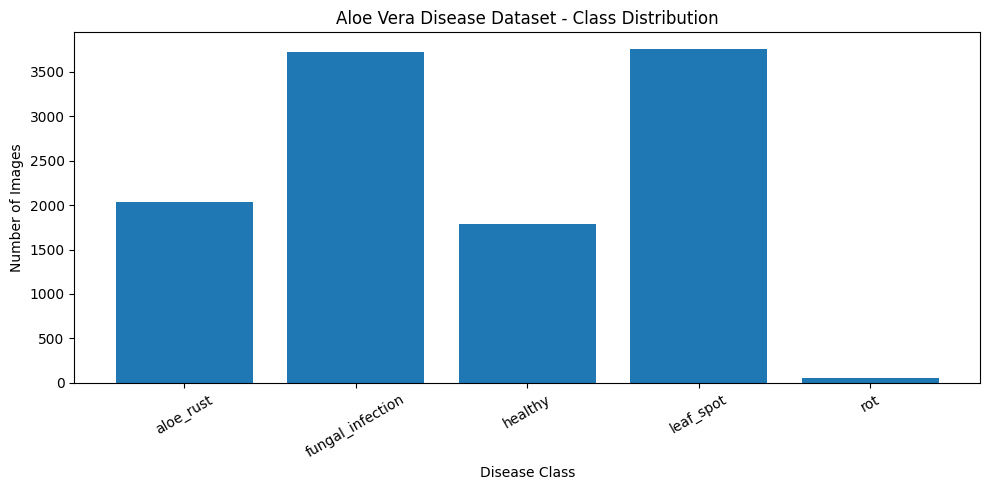

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(
    CLASSES,
    [counts[c] for c in CLASSES]
)

plt.title("Aloe Vera Disease Dataset - Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

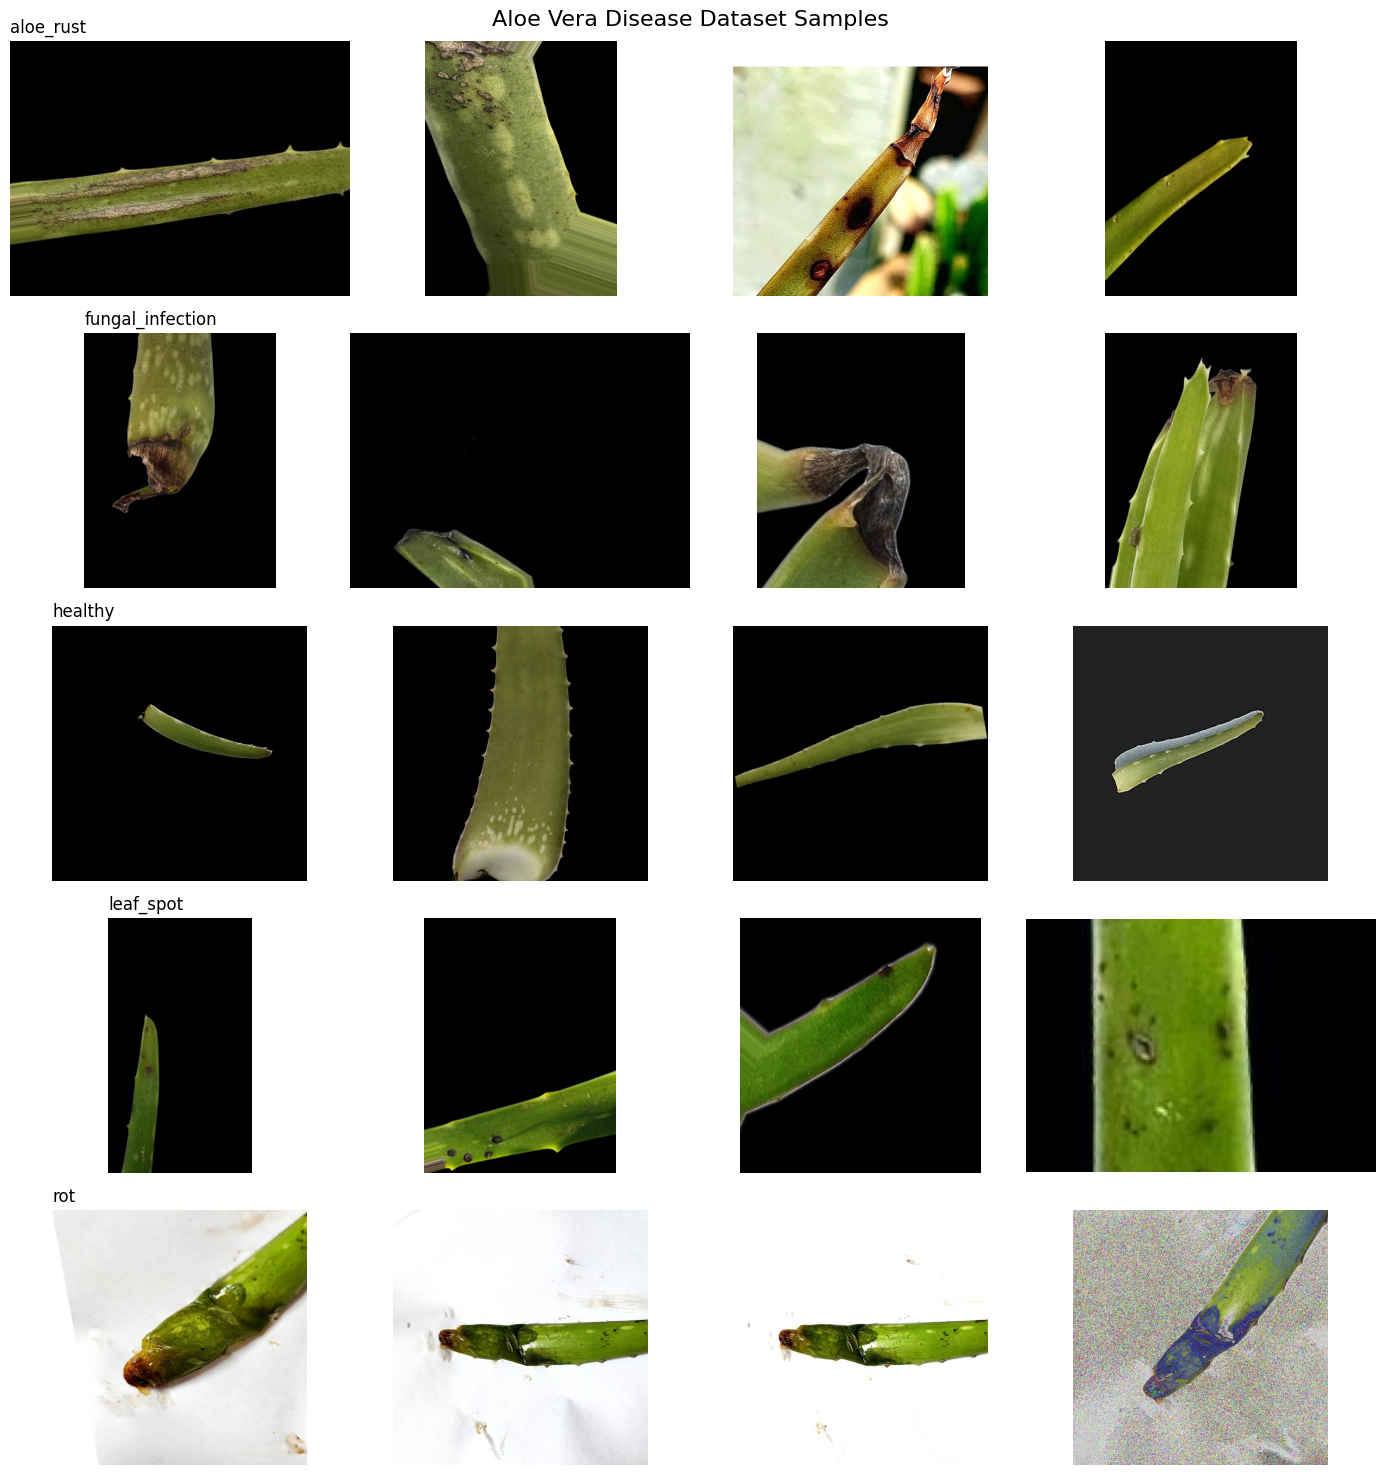

In [7]:
def show_samples(
    paths,
    labels,
    title,
    n=4
):

    classes = sorted(set(labels))

    fig, axes = plt.subplots(
        len(classes),
        n,
        figsize=(14, 3 * len(classes)),
        squeeze=False
    )

    rng = random.Random(42)

    for ax in axes.ravel():
        ax.axis("off")

    for row, cls in enumerate(classes):

        pool = [
            p
            for p, l in zip(paths, labels)
            if l == cls
        ]

        selected = rng.sample(
            pool,
            min(n, len(pool))
        )

        for col, path in enumerate(selected):

            image = Image.open(path).convert("RGB")

            axes[row][col].imshow(image)

            if col == 0:
                axes[row][col].set_title(
                    cls,
                    loc="left",
                    fontsize=12
                )

            axes[row][col].axis("off")

    fig.suptitle(
        title,
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


show_samples(
    all_paths,
    all_labels,
    "Aloe Vera Disease Dataset Samples"
)

In [8]:
def md5(path):

    with open(path, "rb") as f:
        return hashlib.md5(
            f.read()
        ).hexdigest()


def ahash(path):

    image = (
        Image.open(path)
        .convert("L")
        .resize((8, 8), Image.BILINEAR)
    )

    array = np.asarray(
        image,
        dtype=float
    )

    return "".join(
        "1" if value else "0"
        for value in (array > array.mean()).ravel()
    )


def duplicate_report(
    name,
    paths,
    train_md5,
    train_ahash
):

    exact = sum(
        md5(p) in train_md5
        for p in paths
    )

    near = sum(
        ahash(p) in train_ahash
        for p in paths
    )

    print(
        f"{name:12s}: "
        f"{exact:4d} exact copies | "
        f"{near:4d} exact-or-near copies "
        f"of training photos "
        f"(out of {len(paths)})"
    )


train_md5 = {
    md5(p)
    for p in p_tr
}

train_ahash = {
    ahash(p)
    for p in p_tr
}

duplicate_report(
    "Validation",
    p_va,
    train_md5,
    train_ahash
)

duplicate_report(
    "Test",
    p_te,
    train_md5,
    train_ahash
)

Validation  :    0 exact copies |  373 exact-or-near copies of training photos (out of 1705)
Test        :    0 exact copies |  356 exact-or-near copies of training photos (out of 1706)


In [9]:
AUTOTUNE = tf.data.AUTOTUNE


def load_img(path, label):

    image = tf.io.read_file(path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.cast(
        tf.round(
            tf.clip_by_value(
                image,
                0,
                255
            )
        ),
        tf.uint8
    )

    return image, label


def to_float(image, label):

    return (
        tf.cast(
            image,
            tf.float32
        ),
        label
    )


# ---------------------------------------------------------
# DATA AUGMENTATION
# ---------------------------------------------------------

flip = layers.RandomFlip(
    "horizontal_and_vertical"
)

rotation = layers.RandomRotation(
    0.08,
    fill_mode="reflect"
)

zoom = layers.RandomZoom(
    (-0.25, 0.10),
    fill_mode="reflect"
)


def augment(image, label):

    x = tf.cast(
        image,
        tf.float32
    )

    x = flip(
        x,
        training=True
    )

    x = rotation(
        x,
        training=True
    )

    x = zoom(
        x,
        training=True
    )

    x = x / 255.0

    # Brightness
    x = x * tf.random.uniform(
        [],
        0.75,
        1.25
    )

    # Contrast
    x = tf.image.random_contrast(
        x,
        0.8,
        1.2
    )

    # Saturation
    x = tf.image.random_saturation(
        tf.clip_by_value(
            x,
            0,
            1
        ),
        0.8,
        1.2
    )

    # Small colour variation
    x = x * tf.random.uniform(
        [3],
        0.92,
        1.08
    )

    x = tf.clip_by_value(
        x,
        0.0,
        1.0
    )

    x = x * 255.0

    return x, label


def make_ds(
    paths,
    labels,
    training=False
):

    y = np.array(
        [
            class_to_idx[label]
            for label in labels
        ],
        dtype=np.int32
    )

    ds = tf.data.Dataset.from_tensor_slices(
        (
            np.array(paths),
            y
        )
    )

    ds = ds.map(
        load_img,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.cache()

    if training:

        ds = ds.shuffle(
            len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

        ds = ds.map(
            augment,
            num_parallel_calls=AUTOTUNE
        )

    else:

        ds = ds.map(
            to_float,
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(BATCH)

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds


train_ds = make_ds(
    p_tr,
    y_tr,
    training=True
)

val_ds = make_ds(
    p_va,
    y_va,
    training=False
)

test_ds = make_ds(
    p_te,
    y_te,
    training=False
)

print("Datasets created successfully.")

I0000 00:00:1790061653.212760      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790061653.215581      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets created successfully.


In [10]:
train_y_numeric = np.array(
    [
        class_to_idx[label]
        for label in y_tr
    ]
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(K),
    y=train_y_numeric
)

class_weight = {
    i: float(weight)
    for i, weight in enumerate(
        class_weights_array
    )
}

print("Class weights:")

for i, cls in enumerate(CLASSES):

    print(
        f"{cls:25s} : "
        f"{class_weight[i]:.3f}"
    )

Class weights:
aloe_rust                 : 1.118
fungal_infection          : 0.610
healthy                   : 1.269
leaf_spot                 : 0.605
rot                       : 38.810


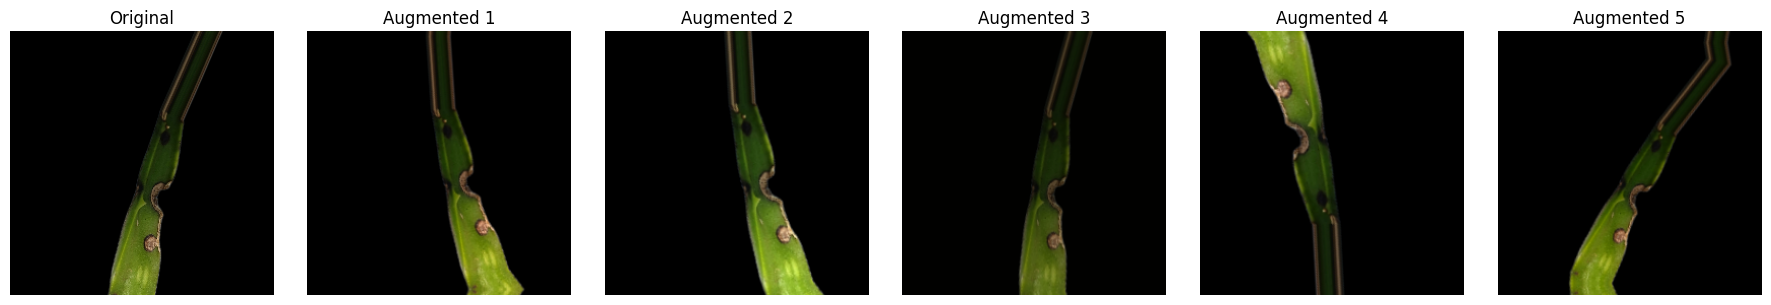

In [11]:
img0, _ = load_img(
    p_tr[0],
    0
)

fig, axes = plt.subplots(
    1,
    6,
    figsize=(18, 3)
)

axes[0].imshow(
    img0.numpy()
)

axes[0].set_title(
    "Original"
)

for i in range(1, 6):

    augmented_img = augment(
        img0,
        0
    )[0]

    axes[i].imshow(
        augmented_img.numpy().astype("uint8")
    )

    axes[i].set_title(
        f"Augmented {i}"
    )

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
def build_model():

    Base = getattr(
        keras.applications,
        MODEL_NAME
    )

    base = Base(
        include_top=False,
        weights=WEIGHTS,
        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        )
    )

    # Freeze base initially
    base.trainable = False

    inputs = keras.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        )
    )

    x = base(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(
        0.3
    )(x)

    outputs = layers.Dense(
        K,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name=f"{PREFIX}_{MODEL_NAME.lower()}"
    )

    return model, base


model, base = build_model()

print(
    "Total parameters:",
    f"{model.count_params():,}"
)

model.summary()

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 7,775,614


Model: "disease_efficientnetb2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         7,045 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,775,614 (29.66 MB)

 Trainable params: 7,045 (27.52 KB)

 Non-trainable params: 7,768,569 (29.63 MB)

In [13]:
def get_callbacks(patience):

    return [

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

In [14]:
print("==========================================")
print("PHASE 1 - CLASSIFIER HEAD TRAINING")
print("==========================================")

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=LR_HEAD
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


h1 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_HEAD,

    class_weight=class_weight,

    callbacks=get_callbacks(
        patience=4
    )
)

PHASE 1 - CLASSIFIER HEAD TRAINING
Epoch 1/10


2026-09-22 07:22:51.144437: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:22:51.294633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:22:51.667307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:22:51.811513: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:22:52.611576: E external/local_xla/xla/stream_

248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.5221 - loss: 1.1029

2026-09-22 07:24:16.605030: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:24:16.748552: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:24:17.098789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:24:17.242860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:24:18.019132: E external/local_xla/xla/stream_

249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.5225 - loss: 1.1018

2026-09-22 07:25:01.954421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:25:02.094075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:25:02.402398: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:25:02.546148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:25:03.321605: E external/local_xla/xla/stream_

249/249 ━━━━━━━━━━━━━━━━━━━━ 248s 505ms/step - accuracy: 0.6163 - loss: 0.8402 - val_accuracy: 0.7367 - val_loss: 0.6956 - learning_rate: 0.0010
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 68s 275ms/step - accuracy: 0.7169 - loss: 0.5437 - val_accuracy: 0.7572 - val_loss: 0.6066 - learning_rate: 0.0010
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 68s 273ms/step - accuracy: 0.7374 - loss: 0.4892 - val_accuracy: 0.7801 - val_loss: 0.5538 - learning_rate: 0.0010
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 68s 274ms/step - accuracy: 0.7510 - loss: 0.4561 - val_accuracy: 0.7783 - val_loss: 0.5337 - learning_rate: 0.0010
Epoch 5/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 68s 273ms/step - accuracy: 0.7521 - loss: 0.4516 - val_accuracy: 0.7848 - val_loss: 0.5450 - learning_rate: 0.0010
Epoch 6/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 68s 273ms/step - accuracy: 0.7622 - loss: 0.4357 - val_accuracy: 0.7924 - val_loss: 0.5246 - learning_rate: 0.0010
Epoch 7/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 69s 276ms/step - accuracy: 0.7660 - loss

In [15]:
print("==========================================")
print("PHASE 2 - EFFICIENTNET FINE-TUNING")
print("==========================================")

base.trainable = True


# Freeze earlier layers
for layer in base.layers[:-UNFREEZE_LAST]:

    layer.trainable = False


# Keep Batch Normalization layers frozen
for layer in base.layers:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False


trainable_params = sum(
    int(np.prod(w.shape))
    for w in model.trainable_weights
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)


model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=LR_FT
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


h2 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_FT,

    class_weight=class_weight,

    callbacks=get_callbacks(
        patience=6
    )
)

PHASE 2 - EFFICIENTNET FINE-TUNING
Trainable parameters: 5,527,597
Epoch 1/25


2026-09-22 07:36:03.636500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:36:03.780344: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:36:04.175246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:36:04.318893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:36:04.919496: E external/local_xla/xla/stream_

248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.7775 - loss: 0.4057

2026-09-22 07:37:28.454219: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:37:28.597087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:37:28.890535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:37:29.033423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 07:37:29.315822: E external/local_xla/xla/stream_

249/249 ━━━━━━━━━━━━━━━━━━━━ 143s 415ms/step - accuracy: 0.7906 - loss: 0.3768 - val_accuracy: 0.8123 - val_loss: 0.4426 - learning_rate: 3.0000e-05
Epoch 2/25
249/249 ━━━━━━━━━━━━━━━━━━━━ 69s 278ms/step - accuracy: 0.8169 - loss: 0.3235 - val_accuracy: 0.8563 - val_loss: 0.3386 - learning_rate: 3.0000e-05
Epoch 3/25
249/249 ━━━━━━━━━━━━━━━━━━━━ 69s 277ms/step - accuracy: 0.8326 - loss: 0.2900 - val_accuracy: 0.8457 - val_loss: 0.3747 - learning_rate: 3.0000e-05
Epoch 4/25
249/249 ━━━━━━━━━━━━━━━━━━━━ 69s 277ms/step - accuracy: 0.8544 - loss: 0.2554 - val_accuracy: 0.8868 - val_loss: 0.2753 - learning_rate: 3.0000e-05
Epoch 5/25
249/249 ━━━━━━━━━━━━━━━━━━━━ 69s 278ms/step - accuracy: 0.8616 - loss: 0.2386 - val_accuracy: 0.8933 - val_loss: 0.2607 - learning_rate: 3.0000e-05
Epoch 6/25
249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 278ms/step - accuracy: 0.8749 - loss: 0.2192 - val_accuracy: 0.9085 - val_loss: 0.2260 - learning_rate: 3.0000e-05
Epoch 7/25
249/249 ━━━━━━━━━━━━━━━━━━━━ 70s 280ms/step -

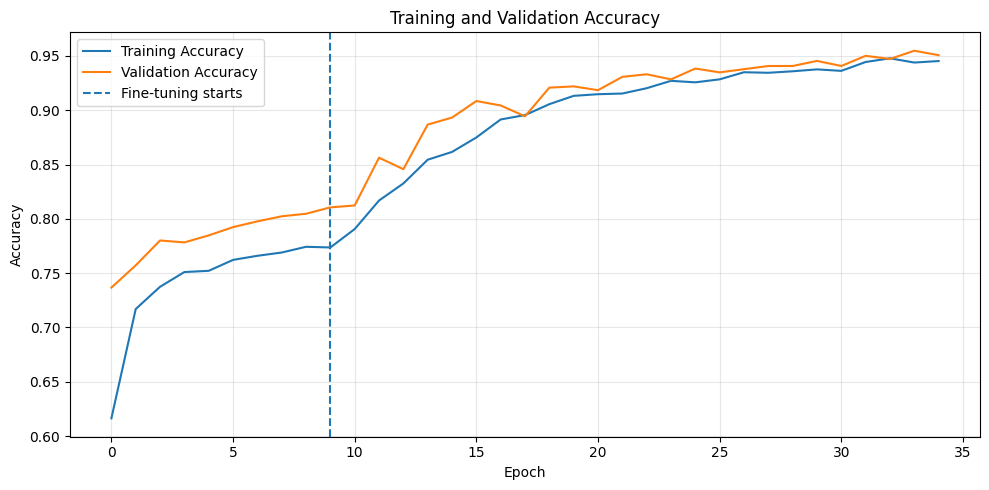

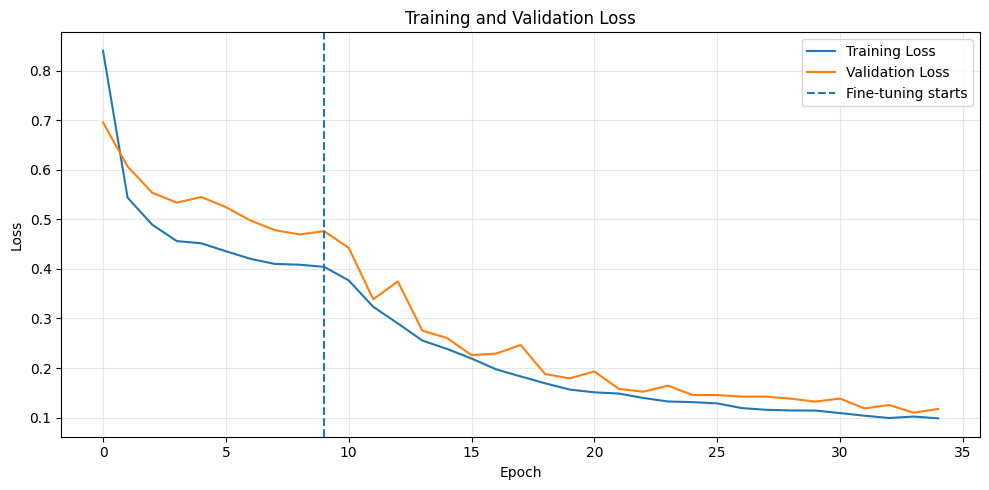

In [16]:
# Combine both training histories

accuracy = (
    h1.history["accuracy"]
    +
    h2.history["accuracy"]
)

val_accuracy = (
    h1.history["val_accuracy"]
    +
    h2.history["val_accuracy"]
)

loss = (
    h1.history["loss"]
    +
    h2.history["loss"]
)

val_loss = (
    h1.history["val_loss"]
    +
    h2.history["val_loss"]
)

phase1_epochs = len(
    h1.history["loss"]
)


# ---------------------------------------------------------
# ACCURACY
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    accuracy,
    label="Training Accuracy"
)

plt.plot(
    val_accuracy,
    label="Validation Accuracy"
)

plt.axvline(
    phase1_epochs - 1,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# LOSS
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    loss,
    label="Training Loss"
)

plt.plot(
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    phase1_epochs - 1,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [17]:
print("==========================================")
print("TEST SET EVALUATION")
print("==========================================")

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print()
print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

TEST SET EVALUATION
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9494 - loss: 0.1461

2026-09-22 08:06:40.240845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 08:06:40.379915: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 08:06:40.703411: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 08:06:40.846845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 08:06:41.625634: E external/local_xla/xla/stream_

54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 589ms/step - accuracy: 0.9496 - loss: 0.1387

Test Loss     : 0.1387
Test Accuracy : 94.96%


In [18]:
print("Generating predictions...")

test_probs = model.predict(
    test_ds,
    verbose=1
)

test_predictions = np.argmax(
    test_probs,
    axis=1
)

y_test = np.array(
    [
        class_to_idx[label]
        for label in y_te
    ]
)

print("Predictions generated.")

Generating predictions...
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 235ms/step
Predictions generated.


In [19]:
print(
    classification_report(
        y_test,
        test_predictions,
        labels=IDX,
        target_names=CLASSES,
        digits=4,
        zero_division=0
    )
)

                  precision    recall  f1-score   support

       aloe_rust     0.9381    0.9443    0.9412       305
fungal_infection     0.9438    0.9589    0.9513       560
         healthy     1.0000    1.0000    1.0000       268
       leaf_spot     0.9367    0.9184    0.9275       564
             rot     1.0000    1.0000    1.0000         9

        accuracy                         0.9496      1706
       macro avg     0.9637    0.9643    0.9640      1706
    weighted avg     0.9496    0.9496    0.9495      1706



In [20]:
accuracy = accuracy_score(
    y_test,
    test_predictions
)

macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

print(
    f"Test Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Macro F1 Score: {macro_f1:.4f}"
)

Test Accuracy : 94.96%
Macro F1 Score: 0.9640


In [21]:
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=IDX
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[288   4   0  13   0]
 [  1 537   0  22   0]
 [  0   0 268   0   0]
 [ 18  28   0 518   0]
 [  0   0   0   0   9]]


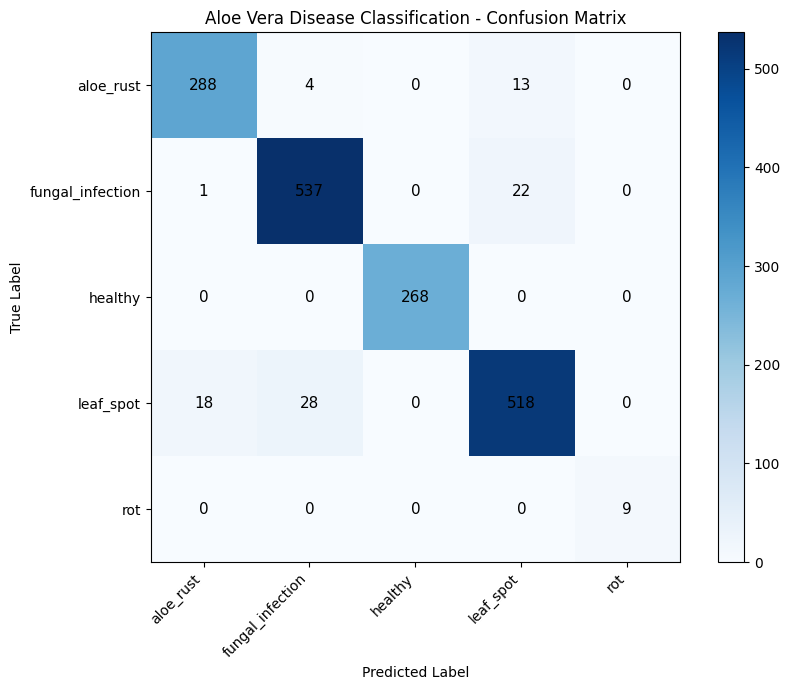

In [22]:
plt.figure(
    figsize=(9, 7)
)

plt.imshow(
    cm,
    cmap="Blues"
)

plt.title(
    "Aloe Vera Disease Classification - Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    IDX,
    CLASSES,
    rotation=45,
    ha="right"
)

plt.yticks(
    IDX,
    CLASSES
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)


# Add values inside cells
for i in IDX:

    for j in IDX:

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=11
        )


plt.tight_layout()

plt.show()

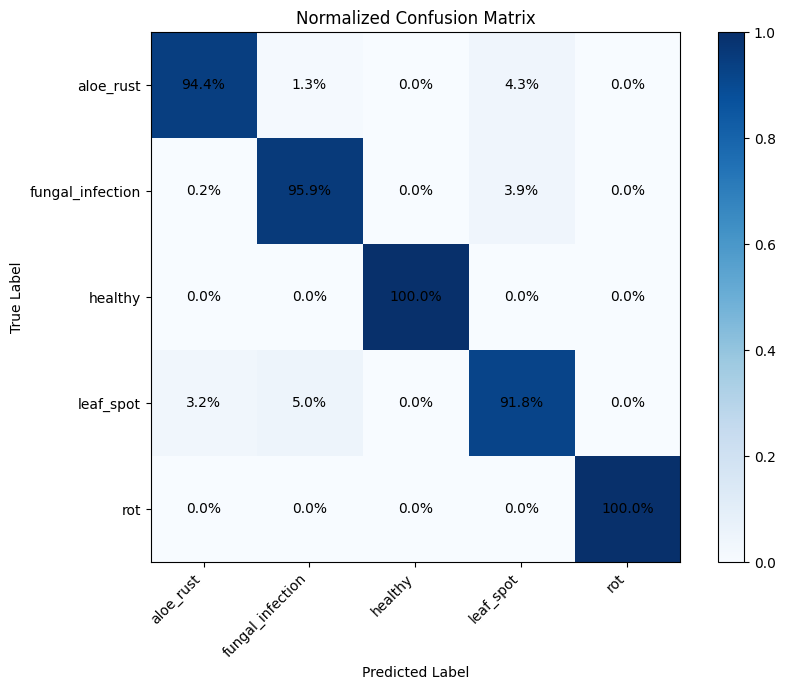

In [23]:
cm_normalized = (
    cm.astype("float")
    /
    cm.sum(
        axis=1,
        keepdims=True
    )
)

plt.figure(
    figsize=(9, 7)
)

plt.imshow(
    cm_normalized,
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title(
    "Normalized Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    IDX,
    CLASSES,
    rotation=45,
    ha="right"
)

plt.yticks(
    IDX,
    CLASSES
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

for i in IDX:

    for j in IDX:

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j] * 100:.1f}%",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

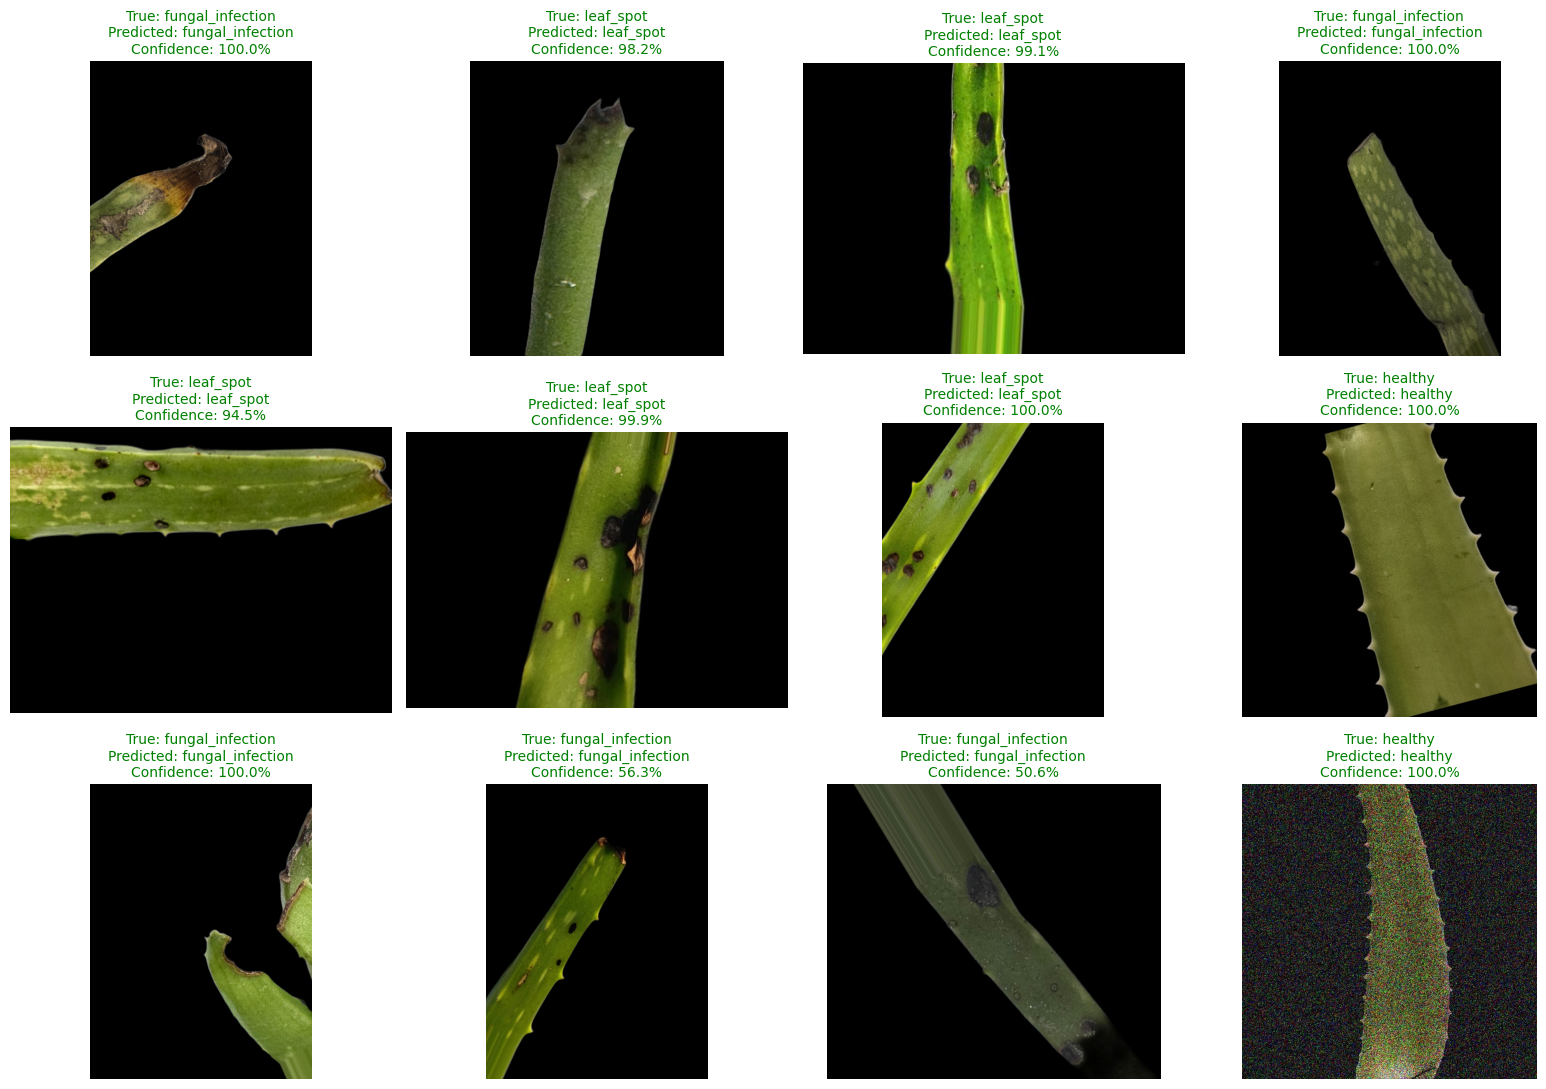

In [24]:
def show_predictions(
    paths,
    true_labels,
    predicted_indices,
    probabilities,
    n=12
):

    n = min(
        n,
        len(paths)
    )

    indices = np.random.choice(
        len(paths),
        n,
        replace=False
    )

    rows = 3
    cols = 4

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(16, 11)
    )

    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(
        axes,
        indices
    ):

        image = Image.open(
            paths[idx]
        ).convert("RGB")

        ax.imshow(image)

        true_class = true_labels[idx]

        predicted_class = CLASSES[
            predicted_indices[idx]
        ]

        confidence = (
            probabilities[idx].max()
            * 100
        )

        color = (
            "green"
            if true_class == predicted_class
            else "red"
        )

        ax.set_title(
            f"True: {true_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence:.1f}%",
            color=color,
            fontsize=10
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(
    p_te,
    y_te,
    test_predictions,
    test_probs,
    n=12
)

In [25]:
print("==========================================")
print("MOST COMMON CLASSIFICATION ERRORS")
print("==========================================")

errors = []

for i in IDX:

    for j in IDX:

        if i != j and cm[i, j] > 0:

            errors.append(
                (
                    cm[i, j],
                    CLASSES[i],
                    CLASSES[j]
                )
            )

errors.sort(
    reverse=True
)

for count, true_cls, pred_cls in errors[:10]:

    print(
        f"{count:4d} : "
        f"True = {true_cls:20s} "
        f"Predicted = {pred_cls}"
    )

MOST COMMON CLASSIFICATION ERRORS
  28 : True = leaf_spot            Predicted = fungal_infection
  22 : True = fungal_infection     Predicted = leaf_spot
  18 : True = leaf_spot            Predicted = aloe_rust
  13 : True = aloe_rust            Predicted = leaf_spot
   4 : True = aloe_rust            Predicted = fungal_infection
   1 : True = fungal_infection     Predicted = aloe_rust


In [26]:
healthy_index = class_to_idx["healthy"]

true_healthy = (
    y_test == healthy_index
)

pred_healthy = (
    test_predictions == healthy_index
)

binary_accuracy = (
    true_healthy == pred_healthy
).mean()

print(
    f"Healthy vs Diseased Accuracy: "
    f"{binary_accuracy * 100:.2f}%"
)

false_healthy = (
    (~true_healthy) &
    pred_healthy
).sum()

healthy_as_diseased = (
    true_healthy &
    (~pred_healthy)
).sum()

print(
    "Diseased images predicted as Healthy:",
    int(false_healthy)
)

print(
    "Healthy images predicted as Diseased:",
    int(healthy_as_diseased)
)

Healthy vs Diseased Accuracy: 100.00%
Diseased images predicted as Healthy: 0
Healthy images predicted as Diseased: 0


In [27]:
model_file = (
    f"{OUT_DIR}/"
    f"{PREFIX}_{MODEL_NAME.lower()}.keras"
)

labels_file = (
    f"{OUT_DIR}/"
    f"{PREFIX}_{MODEL_NAME.lower()}_labels.txt"
)

# Save model
model.save(
    model_file
)

# Save class labels
Path(labels_file).write_text(
    "\n".join(CLASSES)
)

print("Model saved:")
print(model_file)

print()

print("Labels saved:")
print(labels_file)

Model saved:
/kaggle/working/disease_efficientnetb2.keras

Labels saved:
/kaggle/working/disease_efficientnetb2_labels.txt


In [28]:
print("Loading saved model...")

loaded_model = keras.models.load_model(
    model_file
)

print(
    "Model successfully loaded."
)

print(
    "Model name:",
    loaded_model.name
)

print(
    "Number of classes:",
    len(CLASSES)
)

Loading saved model...
Model successfully loaded.
Model name: disease_efficientnetb2
Number of classes: 5
